# When standard stats meets a human being: a tennis laboratory

**Question.** How much of the comfortable machinery of simple textbook statistics survives
contact with a process that has (i) *absorbing barriers*, (ii) *serial correlation*, and
(iii) *parameter uncertainty*? Tennis is a fun and (maybe) clean place to ask, because the
bottom of the process really is a  simple Bernoulli trial. Everything above it is then just
bookkeeping that we control exactly. Not bad, and also 100% generally not the case.

**The set-up.** Player A wins any given point with probability $p$; player B wins with
$q = 1-p$. Under the textbook assumptions the number of points A wins in $n$ points is
*exactly* $\mathrm{Binomial}(n,p)$, and $\hat p$ has standard error $\sqrt{p(1-p)/n}$.

### Failure modes of naive intuition

**1. The aggregation is nonlinear (absorbing barriers).**
Tennis does not count points. It counts *games* (first to 4, win by 2), *sets* (first to 6
games, win by 2, tiebreak at 6-6) and *matches* (best of 3 or 5). Each layer is a stopping
problem with absorbing barriers, and the composition $f(p) = \mathbb{P}(\text{A wins the match})$ 
is a violently steep S-curve. It is trivial to say, but scoring a point and winning a game are 
not the same thing. And they do not carry the same probability given a set chance of winning a point.
**This failure mode is present even with perfectly i.i.d. points.** 

**2. Points are serially correlated (momentum, the hot hand).**
We let the point-win probability depend on the previous point:

$$p_t = \sigma\!\big(\mathrm{logit}(p) + c + k\,s_{t-1}\big), \qquad s_{t-1}\in\{-1,+1\}$$

The offset $c$ is solved numerically so the *stationary* win probability stays exactly $p$.
That calibration is crucial here: switching correlation on then changes the **variance and the path               structure without moving the mean**, so anything we observe is attributable to dependence alone.
We will play with a moving $p$ later for sure.

### A first result we will be able to show clearly

For the order-1 chain with lag-1 autocorrelation $\rho$,

$$\frac{\mathrm{Var}(S_n)}{n\,p(1-p)} \;\longrightarrow\; \frac{1+\rho}{1-\rho}$$

A CLT *still holds*. What fails is the **naive variance one would have plugged in**.
At $\rho=0.5$ the error bars are too small by a factor of $\sqrt3$ and 1000 observations are worth 333.
Correlation of this kind does not produces fat tails. Rather, it can get people overconfident and cost them money.

**3. The memory can be long, and the format can hide it.**
Richer memory is not automatically longer memory. Replacing the order-1 chain with a
run-length hazard $h(\ell)=\beta/(\ell+\gamma)$ gives a Pareto tail
$\mathbb{P}(L>\ell)\sim C\ell^{-\beta}$, and for $1<\beta<2$ the sum $\sum_h\rho_h$ diverges,
$\mathrm{Var}(S_n)$ scales as $n^{3-\beta}$ rather than $n$, and the $\sqrt n$ machinery fails
at the level of the *exponent* rather than the constant. Part 7 builds this and then does the
thing the notebook is actually about: measures it **inside real matches**, where the scoring
hierarchy caps every run at 53 points. The tail we specified is simply deleted, and with it
any hope of detecting the regime that generated the data.

### One sentence on what we are really doing

Each part isolates a different way the chain of reasoning from *"a limit theorem applies"* to
*"therefore my error bars are $\sqrt{p(1-p)/n}$ and I may report $f(\hat p)$"* breaks down.
In none of them does the theorem turn out to be false. Every failure is in a step someone
took silently on the way from the theorem to the number.


In [16]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from tennis_lab import (
    TennisSimulator,
    game_win_probability,
    set_win_probability,
    match_win_probability_iid,
    run_hazard,
    run_survival,
    hurst_from_beta,
    gamma_for_mean_run,
    run_hazard,
    run_survival,
    hurst_from_beta,
)

SEED = 20260803
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titlesize": 11,
    "legend.frameon": False,
})
C0, C1, C2, C3 = "#1f4e79", "#c0392b", "#e08a1e", "#2e7d5b"

_lgamma = np.vectorize(math.lgamma)

def binom_pmf(n, p, k=None):
    '''Binomial pmf via log-gamma (avoids a scipy dependency).'''
    k = np.arange(n + 1) if k is None else np.asarray(k, dtype=float)
    logp = (_lgamma(n + 1) - _lgamma(k + 1) - _lgamma(n - k + 1)
            + k * np.log(p) + (n - k) * np.log1p(-p))
    return np.exp(logp)

def norm_ppf(q):
    '''Acklam rational approximation to the standard normal quantile function.'''
    a = (-3.969683028665376e+01, 2.209460984245205e+02, -2.759285104469687e+02,
         1.383577518672690e+02, -3.066479806614716e+01, 2.506628277459239e+00)
    b = (-5.447609879822406e+01, 1.615858368580409e+02, -1.556989798598866e+02,
         6.680131188771972e+01, -1.328068155288572e+01)
    c = (-7.784894002430293e-03, -3.223964580411365e-01, -2.400758277161838e+00,
         -2.549732539343734e+00, 4.374664141464968e+00, 2.938163982698783e+00)
    d = (7.784695709041462e-03, 3.224671290700398e-01, 2.445134137142996e+00,
         3.754408661907416e+00)
    q = np.asarray(q, dtype=float)
    out = np.empty_like(q)
    plow, phigh = 0.02425, 1 - 0.02425
    lo, hi = q < plow, q > phigh
    mid = ~(lo | hi)

    def tail(x):
        return (((((c[0]*x + c[1])*x + c[2])*x + c[3])*x + c[4])*x + c[5]) / \
               ((((d[0]*x + d[1])*x + d[2])*x + d[3])*x + 1)

    if lo.any():
        x = np.sqrt(-2 * np.log(q[lo])); out[lo] = tail(x)
    if hi.any():
        x = np.sqrt(-2 * np.log1p(-q[hi])); out[hi] = -tail(x)
    if mid.any():
        u = q[mid] - 0.5; r = u * u
        out[mid] = (((((a[0]*r + a[1])*r + a[2])*r + a[3])*r + a[4])*r + a[5]) * u / \
                   (((((b[0]*r + b[1])*r + b[2])*r + b[3])*r + b[4])*r + 1)
    return out

def run_lengths(path, value=1):
    '''Lengths of maximal runs of `value` in a 1-D 0/1 array.'''
    x = np.asarray(path) == value
    if not x.any():
        return np.array([], dtype=int)
    d = np.diff(np.concatenate(([0], x.view(np.int8), [0])))
    return np.flatnonzero(d == -1) - np.flatnonzero(d == 1)

print("ready")

ready


---
## Part 0 — The baseline: i.i.d. points really are binomial

A sanity check on the machinery. With `k = 0` the simulator emits independent Bernoulli
points, so the count over $n$ points must land exactly on $\mathrm{Binomial}(n,p)$. 

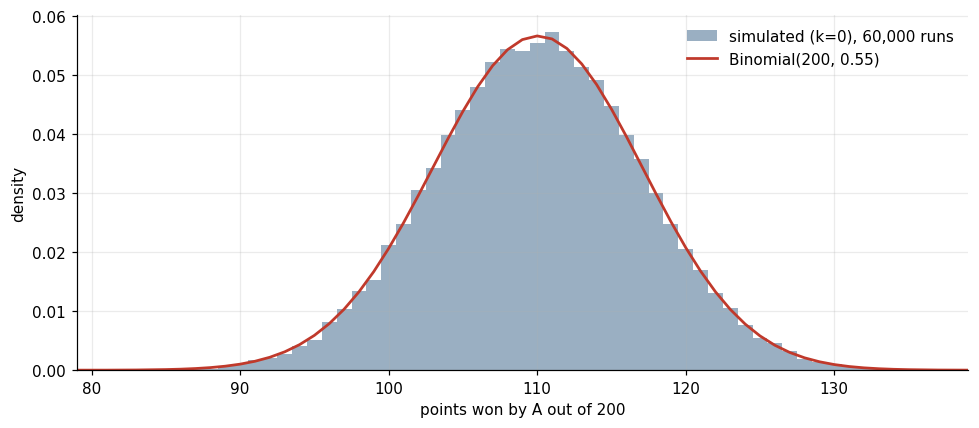

simulated mean  110.0276   binomial mean  110.0000
simulated var    49.2850   binomial var    49.5000


In [17]:
p, n_pts, n_seq = 0.55, 200, 60_000

sim0 = TennisSimulator(p=p, k=0.0, seed=SEED)
counts0 = sim0.simulate_point_sequences(n_seq, n_pts)

k_grid = np.arange(n_pts + 1)
pmf = binom_pmf(n_pts, p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(counts0, bins=np.arange(counts0.min() - .5, counts0.max() + 1.5),
        density=True, color=C0, alpha=.45, label=f"simulated (k=0), {n_seq:,} runs")
ax.plot(k_grid, pmf, color=C1, lw=1.8, label=f"Binomial({n_pts}, {p})")
ax.set_xlim(counts0.min() - 2, counts0.max() + 2)
ax.set_xlabel(f"points won by A out of {n_pts}"); ax.set_ylabel("density")
ax.legend()
plt.tight_layout(); plt.show()

print(f"simulated mean {counts0.mean():9.4f}   binomial mean {n_pts*p:9.4f}")
print(f"simulated var  {counts0.var(ddof=1):9.4f}   binomial var  {n_pts*p*(1-p):9.4f}")

---
## Part 1 — Absorbing barriers alone are already enough to make you wrong

As first thing, it was quite a good choice to look at what the *scoring system* does.
Points are still perfectly i.i.d. — the CLT holds in full — and yet the quantity anyone would actually 
care about, $f(p) = \mathbb{P}(\text{A wins the match})$, behaves nothing like $p$. *They are not 
the same thing!*

Every layer of tennis is a *first-to-N, win-by-2* race: an absorbing-barrier problem! It is very fun how this 
produces nonlinear transformation in the probability curves to win different units of the game.

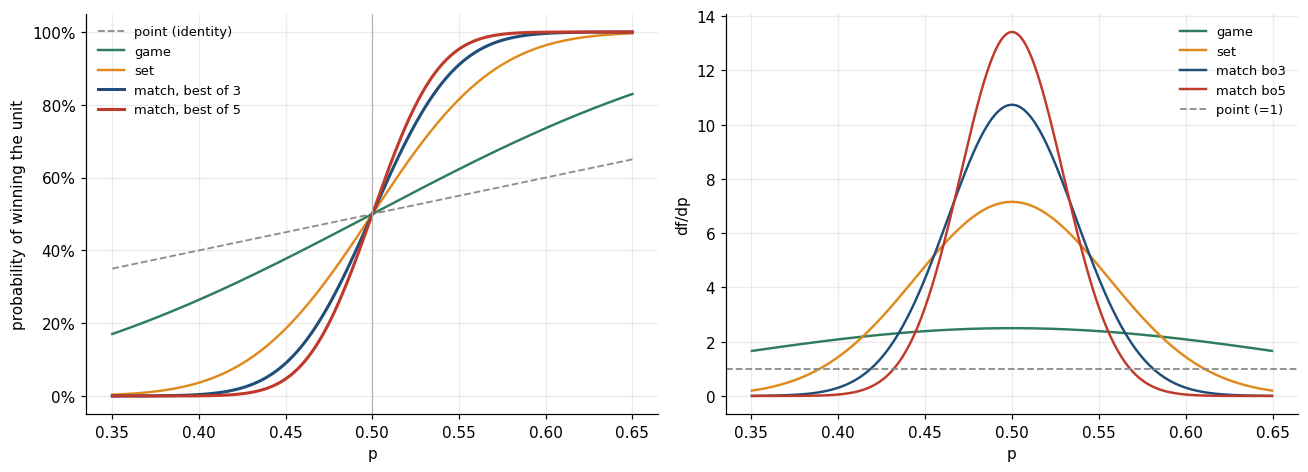

,P(game),P(set),"P(match, bo3)","P(match, bo5)"
p (point),,,,
0.500000,0.5000,0.5000,0.5000,0.5000
0.510000,0.5250,0.5712,0.6060,0.6317
0.520000,0.5499,0.6401,0.7047,0.7493
0.550000,0.6231,0.8150,0.9100,0.9530
0.600000,0.7357,0.9634,0.9961,0.9995


In [18]:
pg = np.linspace(0.35, 0.65, 601)
f_game  = np.array([game_win_probability(x, 4)         for x in pg])
f_set   = np.array([set_win_probability(x)             for x in pg])
f_bo3   = np.array([match_win_probability_iid(x, 3)    for x in pg])
f_bo5   = np.array([match_win_probability_iid(x, 5)    for x in pg])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

ax1.plot(pg, pg,     color="0.55", lw=1.2, ls="--", label="point (identity)")
ax1.plot(pg, f_game, color=C3, lw=1.6, label="game")
ax1.plot(pg, f_set,  color=C2, lw=1.6, label="set")
ax1.plot(pg, f_bo3,  color=C0, lw=2.0, label="match, best of 3")
ax1.plot(pg, f_bo5,  color=C1, lw=2.0, label="match, best of 5")
ax1.axvline(0.5, color="0.7", lw=.8)
ax1.set_xlabel("p")
ax1.set_ylabel("probability of winning the unit")
ax1.legend(loc="upper left", fontsize=8.5)
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))

for arr, lab, col in [(f_game, "game", C3), (f_set, "set", C2),
                      (f_bo3, "match bo3", C0), (f_bo5, "match bo5", C1)]:
    ax2.plot(pg[1:-1], np.gradient(arr, pg)[1:-1], color=col, lw=1.6, label=lab)
ax2.axhline(1, color="0.55", ls="--", lw=1.2, label="point (=1)")
ax2.set_xlabel("p"); ax2.set_ylabel("df/dp")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

rows = []
for x in (0.500, 0.510, 0.520, 0.550, 0.600):
    rows.append({"p (point)": x,
                 "P(game)": game_win_probability(x, 4),
                 "P(set)": set_win_probability(x),
                 "P(match, bo3)": match_win_probability_iid(x, 3),
                 "P(match, bo5)": match_win_probability_iid(x, 5)})
tbl = pd.DataFrame(rows).set_index("p (point)")
display(tbl.style.format("{:.4f}").set_caption("Amplification through the scoring hierarchy"))

A player who wins **51%** of points — a difference I would defenitely miss, and one you would 
need thousands of points to detect — wins **60.6%** of best-of-3 matches and **63.2%** of 
best-of-5 matches. At **55%** of points he wins **91%** of matches. At 60% they essentially 
never lose. The probability curve f(p) seems to reach a plateau very fast. 

Here, the right panel clearly shows the sensitivity of these probability curves: at $p=0.5$, 
$\mathrm{d}f/\mathrm{d}p = 10.7$ for a best-of-3 match and $13.4$ for best-of-5. 
**Every unit of error in your estimate of $p$ is multiplied by more than ten before it reaches                         the quantity we would really care about.** To wit, those absorbing barriers are doing some 
heavy lifting (not as much in as in a ruin-based problem, but still...)

*(Aside: I think this is also exactly why best-of-5 is used for the men's Grand Slams. Longer format
= more absorbing barriers crossed = more amplification = less chance the better player loses.
The format is essentially a variance-reduction device. Mind you, I doubt they made similar simulations,
I reckon they just went for "longer the game, more chances ability rather than luck comes out")*

---
## Part 2 — Switching on correlation

Now we let (short-range) correlation play a role. First, the analytic characterisation of what each $k$
actually does. Note `stationary_p` stays pinned at 0.55 by construction — the calibration is
working, so the mean is held fixed and only the dependence structure changes.

In [19]:
ks = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5]
info = pd.DataFrame([TennisSimulator(p=0.55, k=k).summary() for k in ks])
info = info[["k", "P(win|won last)", "P(win|lost last)", "stationary_p", "rho",
             "variance_inflation", "n_eff_over_n", "mean_run_length_A"]]
display(info.style.format({"k": "{:.2f}", "P(win|won last)": "{:.4f}",
                           "P(win|lost last)": "{:.4f}", "stationary_p": "{:.6f}",
                           "rho": "{:.4f}", "variance_inflation": "{:.3f}",
                           "n_eff_over_n": "{:.3f}", "mean_run_length_A": "{:.2f}"})
        .hide(axis="index")
        .set_caption("What each momentum strength k actually means (p = 0.55)"))

k,P(win|won last),P(win|lost last),stationary_p,rho,variance_inflation,n_eff_over_n,mean_run_length_A
0.00,0.5500,0.5500,0.550000,0.0000,1.000,1.000,2.22
0.25,0.6055,0.4821,0.550000,0.1234,1.281,0.780,2.53
0.50,0.6595,0.4161,0.550000,0.2434,1.644,0.608,2.94
0.75,0.7105,0.3538,0.550000,0.3567,2.109,0.474,3.45
1.00,0.7572,0.2968,0.550000,0.4604,2.707,0.369,4.12
1.50,0.8352,0.2015,0.550000,0.6337,4.460,0.224,6.07


$k=1.0$ is a strong but not absurd hot hand: after winning a point A wins the next 75.7% of
the time, after losing it only 29.7%. Here, note that their long-run share is still 55%. 
That configuration inflates the variance by a factor of **2.71**, and reduces the effective 
sample size to **37%** of the nominal one. Correlation has some nasty effect on the information
one can extract from a system at times...

Now the distribution of points won.

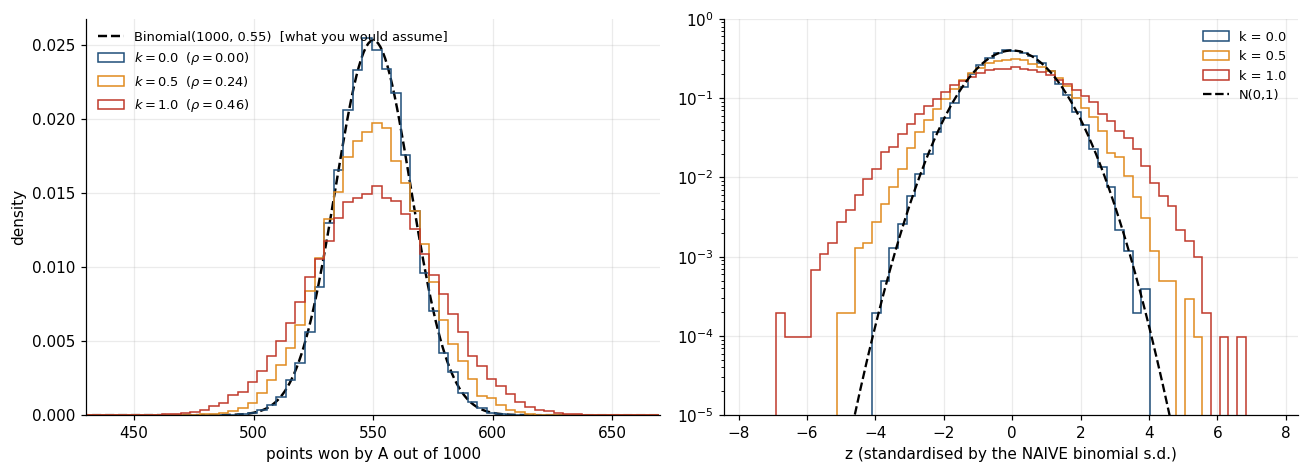

k,rho,mean share,s.d. of count,naive s.d.,P(|z_naive| > 3),P(|z|>3) vs 0.0027
0.00,0.000,0.5501,15.70,15.73,0.0025,0.9x
0.50,0.243,0.5500,20.21,15.73,0.0191,7.1x
1.00,0.460,0.5501,25.82,15.73,0.0665,24.6x


In [20]:
n_pts, n_seq = 1000, 40_000
ks_show = [0.0, 0.5, 1.0]
sims = {k: TennisSimulator(p=0.55, k=k, seed=SEED + i) for i, k in enumerate(ks_show)}
cnts = {k: s.simulate_point_sequences(n_seq, n_pts) for k, s in sims.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
cols = {0.0: C0, 0.5: C2, 1.0: C1}

grid = np.arange(400, 700)
# integer-aligned bins: the counts are discrete, so unaligned bins alias badly
bins = np.arange(429.5, 672, 4)
naive_sd = np.sqrt(n_pts * 0.55 * 0.45)

ax1.plot(grid, binom_pmf(n_pts, 0.55, grid), color="k", lw=1.6, ls="--",
         label=f"Binomial({n_pts}, 0.55)  [what you would assume]")
for k in ks_show:
    ax1.hist(cnts[k], bins=bins, density=True, histtype="step", lw=1.8,
             color=cols[k], label=fr"$k = {k}\;\;(\rho = {sims[k].rho:.2f})$")
ax1.set_xlim(430, 670)
ax1.set_xlabel(f"points won by A out of {n_pts}"); ax1.set_ylabel("density")
ax1.legend(fontsize=8.5, loc = "upper left")

zbins = (bins - n_pts * 0.55) / naive_sd
for k in ks_show:
    z = (cnts[k] - n_pts * 0.55) / naive_sd                       # NAIVE standardisation
    ax2.hist(z, bins=zbins, density=True, histtype="step", lw=1.8, color=cols[k],
             label=f"k = {k}")
zz = np.linspace(-6, 6, 400)
ax2.plot(zz, np.exp(-zz**2 / 2) / np.sqrt(2 * np.pi), color="k", ls="--", lw=1.5,
         label="N(0,1)")
ax2.set_yscale("log"); ax2.set_ylim(1e-5, 1)
ax2.set_xlabel("z (standardised by the NAIVE binomial s.d.)")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

summ = pd.DataFrame({
    "k": ks_show,
    "rho": [sims[k].rho for k in ks_show],
    "mean share": [cnts[k].mean() / n_pts for k in ks_show],
    "s.d. of count": [cnts[k].std(ddof=1) for k in ks_show],
    "naive s.d.": np.sqrt(n_pts * .55 * .45),
    "P(|z_naive| > 3)": [np.mean(np.abs((cnts[k] - n_pts*.55) /
                                        np.sqrt(n_pts*.55*.45)) > 3) for k in ks_show],
})
summ["P(|z|>3) vs 0.0027"] = summ["P(|z_naive| > 3)"] / 0.0027
display(summ.style.format({"k": "{:.2f}", "rho": "{:.3f}", "mean share": "{:.4f}",
                           "s.d. of count": "{:.2f}", "naive s.d.": "{:.2f}",
                           "P(|z_naive| > 3)": "{:.4f}", "P(|z|>3) vs 0.0027": "{:.1f}x"})
        .hide(axis="index"))

The mean is untouched to four decimals, but not the standard deviation. Under the naive binomial
standardisation a "3-sigma" deviation happens about **25 times more often** at $k=1$ than the
0.27% one would budget for. A whopping 6.7% of the time rather than 0.27%.

This looks like the classic mechanism behind risk-model blow-ups. As a personal note, I was really 
surprised by how mild the statistical "spice" to add  is: no jumps, no regime switch, no exotic distribution. 
A rather banal "winning makes you a bit more likely to immediately win again." Not really a complex thing 
to implement whenver humans are involved in the picture.

To be sure, let us check the variance against theory now.

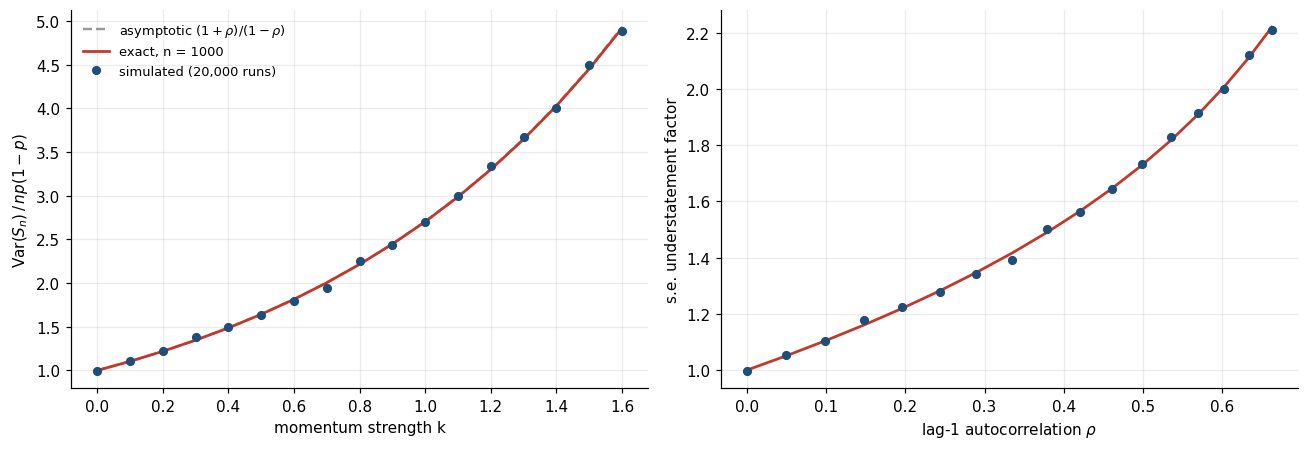

max |simulated - exact| : 0.06519696962106214


In [21]:
k_scan = np.linspace(0, 1.6, 17)
n_pts, n_seq = 1000, 20_000
emp, exact, asym, rhos = [], [], [], []
for i, k in enumerate(k_scan):
    s = TennisSimulator(p=0.55, k=float(k), seed=SEED + 500 + i)
    c = s.simulate_point_sequences(n_seq, n_pts)
    emp.append(c.var(ddof=1) / (n_pts * .55 * .45))
    exact.append(s.exact_variance(n_pts) / (n_pts * .55 * .45))
    asym.append(s.variance_inflation)
    rhos.append(s.rho)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.plot(k_scan, asym,  color="0.6", ls="--", lw=1.6, label=r"asymptotic $(1+\rho)/(1-\rho)$")
ax1.plot(k_scan, exact, color=C1, lw=1.8, label=f"exact, n = {n_pts}")
ax1.plot(k_scan, emp, "o", color=C0, ms=5, label=f"simulated ({n_seq:,} runs)")
ax1.set_xlabel("momentum strength k"); ax1.set_ylabel(r"Var$(S_n)\,/\,np(1-p)$")
ax1.legend(fontsize=8.5)

ax2.plot(rhos, np.sqrt(np.array(asym)), color=C1, lw=1.8)
ax2.plot(rhos, np.sqrt(np.array(emp)), "o", color=C0, ms=5)
ax2.set_xlabel(r"lag-1 autocorrelation $\rho$")
ax2.set_ylabel("s.e. understatement factor")
plt.tight_layout(); plt.show()

print("max |simulated - exact| :", np.max(np.abs(np.array(emp) - np.array(exact))))

Simulation sits on the closed form (good!). Now, two things worth noticing:

- The exact finite-$n$ variance approaches the asymptotic factor **from below**, because the
  covariance sum $\sum_{h}(n-h)\rho^h$ is truncated at $n$. 
- $\sqrt{(1+\rho)/(1-\rho)}$ has a vertical asymptote at $\rho=1$. Note that there is no continuity 
  of consequences here: $\rho = 0.9$ gives error bars too small by a factor of 4.4, $\rho=0.99$
  by a factor of 14. Things get ugly fast.

---
## Part 3 — The visible signature: runs

Correlation is hard to see in a histogram and easy to see in a *path*. The run-length
distribution is then the natural diagnostic — and it is what a commentator is (badly) 
responding to when they say a player is "on fire". 

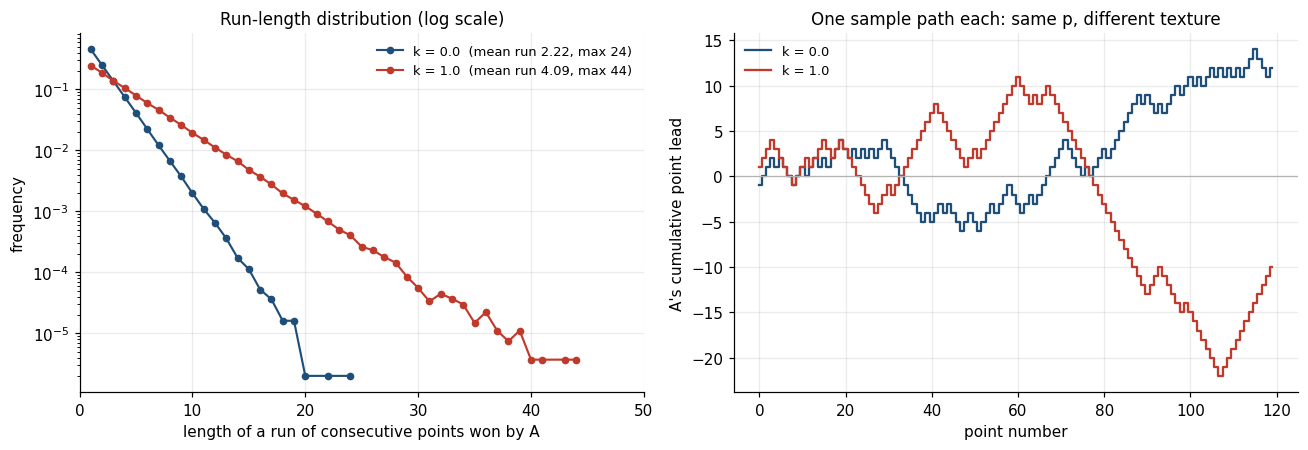

In [22]:
n_pts, n_seq = 500, 4_000
paths = {}
for i, k in enumerate([0.0, 1.0]):
    s = TennisSimulator(p=0.55, k=k, seed=SEED + 900 + i)
    _, pth = s.simulate_point_sequences(n_seq, n_pts, return_paths=True)
    paths[k] = pth

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

for k, col in [(0.0, C0), (1.0, C1)]:
    rl = np.concatenate([run_lengths(paths[k][j]) for j in range(n_seq)])
    vals, cts = np.unique(rl, return_counts=True)
    ax1.plot(vals, cts / cts.sum(), "o-", color=col, ms=4, lw=1.4,
             label=f"k = {k}  (mean run {rl.mean():.2f}, max {rl.max()})")
ax1.set_yscale("log"); ax1.set_xlim(0, 50)
ax1.set_xlabel("length of a run of consecutive points won by A")
ax1.set_ylabel("frequency"); ax1.set_title("Run-length distribution (log scale)")
ax1.legend(fontsize=8.5)

for k, col in [(0.0, C0), (1.0, C1)]:
    ax2.step(np.arange(120), np.cumsum(2 * paths[k][0][:120].astype(int) - 1),
             where="mid", color=col, lw=1.5, label=f"k = {k}")
ax2.axhline(0, color="0.7", lw=.8)
ax2.set_xlabel("point number"); ax2.set_ylabel("A's cumulative point lead")
ax2.set_title("One sample path each: same p, different texture")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

BBy construction, both series have the same 55% mean. However, the correlated one produces
streaks that an observer would confidently call as momentum, confidence, or "they found their rhythm".
Of course, here they would be right - after all we wrote the generator.

Nonetheless, the wider point cuts the other way too: in real data, streaks of this magnitude are *also*
produced by pure independence far more often than we could expect (up to a point, of course!). The run-length 
tail for $k=0$ is not empty. Distinguishing the two requires non-trivial sample sizes. Sadly, we do not 
alwys have acces to these. 

---
## Part 4 — Do we get fat tails? Not from the short-range correlation alone

An order-1 Markov chain with $|\rho| < 1$ is geometrically ergodic. Thus, it satisfies a CLT.
The standardised sum converges to a Gaussian — just with the *long-run* variance
$\sigma^2_{\text{LR}} = p(1-p)\frac{1+\rho}{1-\rho}$ rather than $p(1-p)$. So if we
standardise correctly, normality returns. Hence, excess kurtosis must decay to zero as $n$ grows.

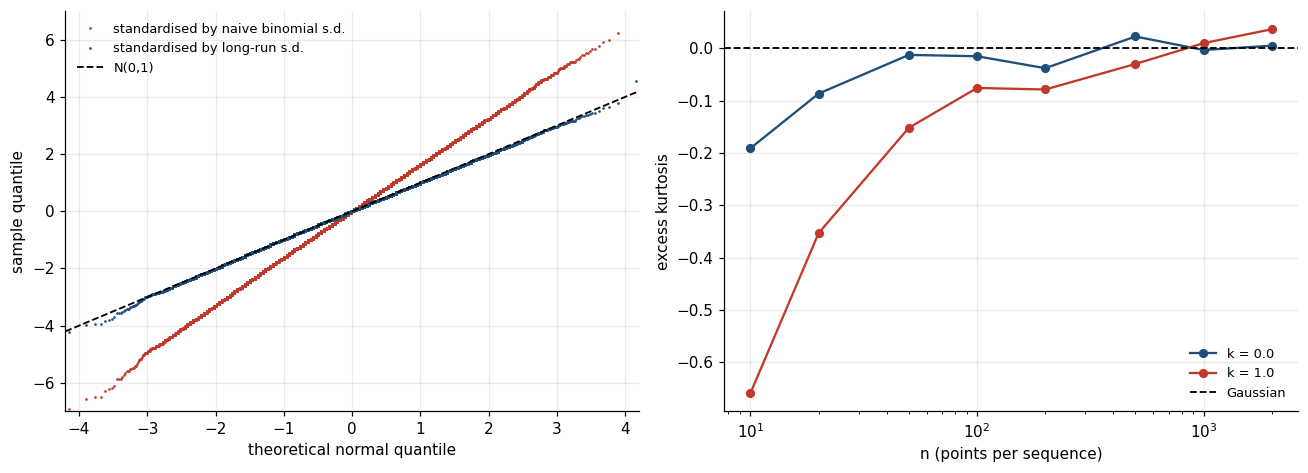

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

# QQ plot at n = 1000, correlated, both standardisations
s = TennisSimulator(p=0.55, k=1.0, seed=SEED + 77)
c = s.simulate_point_sequences(30_000, 1000)
q = (np.arange(1, len(c) + 1) - .5) / len(c)
zt = norm_ppf(q)
naive = np.sort((c - 550) / np.sqrt(1000 * .55 * .45))
correct = np.sort((c - c.mean()) / np.sqrt(s.exact_variance(1000)))
ax1.plot(zt, naive,   ".", ms=1.5, color=C1, label="standardised by naive binomial s.d.")
ax1.plot(zt, correct, ".", ms=1.5, color=C0, label="standardised by long-run s.d.")
ax1.plot([-4.2, 4.2], [-4.2, 4.2], "k--", lw=1.2, label="N(0,1)")
ax1.set_xlim(-4.2, 4.2); ax1.set_ylim(-7, 7)
ax1.set_xlabel("theoretical normal quantile"); ax1.set_ylabel("sample quantile")
ax1.legend(fontsize=8.5, loc="upper left")

# excess kurtosis vs n
ns = [10, 20, 50, 100, 200, 500, 1000, 2000]
for k, col in [(0.0, C0), (1.0, C1)]:
    ex = []
    for i, n in enumerate(ns):
        ss = TennisSimulator(p=0.55, k=k, seed=SEED + 1000 + i)
        cc = ss.simulate_point_sequences(60_000, n).astype(float)
        z = (cc - cc.mean()) / cc.std(ddof=1)
        ex.append(np.mean(z**4) - 3)
    ax2.plot(ns, ex, "o-", color=col, ms=5, lw=1.5, label=f"k = {k}")
ax2.axhline(0, color="k", ls="--", lw=1.2, label="Gaussian")
ax2.set_xscale("log"); ax2.set_xlabel("n (points per sequence)")
ax2.set_ylabel("excess kurtosis")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

- Standardised by the *correct* long-run variance, the correlated sum is clearly Gaussian
  by $n=1000$. Note that the excess kurtosis converges to zero for both $k=0$ and $k=1$.
- Standardised by the variance one could naively *assume*, the same data looks wildly
  fat-tailed — the red cloud fans away from the diagonal.

So "fat tails" here is not a property of the data-generating process. Rather, it is an artefact of
using the wrong scale. That is a maybe even a more problematic feature than even genuine fat tails.
Indeed, every normality test one could run on correctly-standardised residuals will pass,
and they will therefore conclude their model to be fine while being systematically overconfident.
Again, that is how one looses money fast.

Genuine, non-vanishing tail risk requires something stronger: $\rho \to 1$ (long memory,
where the mixing rate loses the race against $n$), or strong randomness in
$p$ itself. Which is where we will go next.

---
## Part 5 — The $\sqrt{n}$ machinery, and what it costs

The rate is still $n^{-1/2}$. The constant is not. This is the practical statement of
effective sample size (i.e., how correlation can be a pain under observation of complex
scenarios).

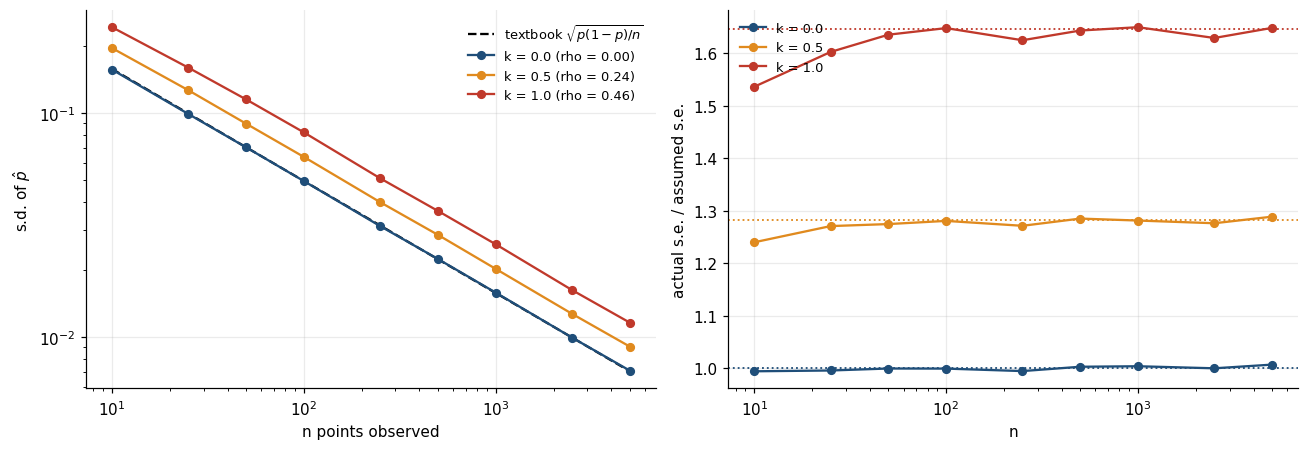

k,rho,n_eff / n,points needed to match k=0 at n=1000
0.0,0.000,1.000,"1,000"
0.5,0.243,0.608,"1,644"
1.0,0.460,0.369,"2,707"


In [24]:
ns = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000]
res = {}
for k in [0.0, 0.5, 1.0]:
    sds = []
    for i, n in enumerate(ns):
        s = TennisSimulator(p=0.55, k=k, seed=SEED + 2000 + i)
        c = s.simulate_point_sequences(30_000, n)
        sds.append((c / n).std(ddof=1))
    res[k] = np.array(sds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ref = np.sqrt(.55 * .45 / np.array(ns))
ax1.loglog(ns, ref, "k--", lw=1.5, label=r"textbook $\sqrt{p(1-p)/n}$")
for k, col in [(0.0, C0), (0.5, C2), (1.0, C1)]:
    ax1.loglog(ns, res[k], "o-", color=col, ms=5, lw=1.5,
               label=f"k = {k} (rho = {TennisSimulator(p=.55,k=k).rho:.2f})")
ax1.set_xlabel("n points observed"); ax1.set_ylabel(r"s.d. of $\hat p$")
ax1.legend(fontsize=8.5)

for k, col in [(0.0, C0), (0.5, C2), (1.0, C1)]:
    ax2.semilogx(ns, res[k] / ref, "o-", color=col, ms=5, lw=1.5, label=f"k = {k}")
    ax2.axhline(np.sqrt(TennisSimulator(p=.55, k=k).variance_inflation),
                color=col, ls=":", lw=1.2)
ax2.set_xlabel("n"); ax2.set_ylabel("actual s.e. / assumed s.e.")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

tab = pd.DataFrame({
    "k": [0.0, 0.5, 1.0],
    "rho": [TennisSimulator(p=.55, k=k).rho for k in (0., .5, 1.)],
    "n_eff / n": [TennisSimulator(p=.55, k=k).effective_sample_size_ratio for k in (0., .5, 1.)],
})
tab["points needed to match k=0 at n=1000"] = 1000 / tab["n_eff / n"]
display(tab.style.format({"k": "{:.1f}", "rho": "{:.3f}", "n_eff / n": "{:.3f}",
                          "points needed to match k=0 at n=1000": "{:,.0f}"})
        .hide(axis="index"))

To learn as much about $p$ from a momentum-driven player as from a memoryless one, we would need
**2,700 points instead of 1,000**. A best-of-3 match contains roughly 150-250 points. Therefore, even
in the benign i.i.d. world, a *single match* would tell us almost nothing about $p$. Now, funnily enough,
with momentum it would tell us about a third of almost nothing. Not quite something I would say.

Now we can recall Part 1: whatever one might have learned about $p$ gets multiplied by ten on its way
to the match-win probability. Tha is why betting on sports is not usually a get-rich-fast-scheme which
works (unless some cheating is involved!)

---
## Part 6 — Correlation at the match level

Let the barriers and the correlation now interact. We can try with a quicl prediction before looking: 
extra variance in the point share gives the underdog more chances to cross a barrier, so momentum should 
drag $\mathbb{P}(\text{favourite wins})$ *toward 50%*. Momentum should help the weaker player.

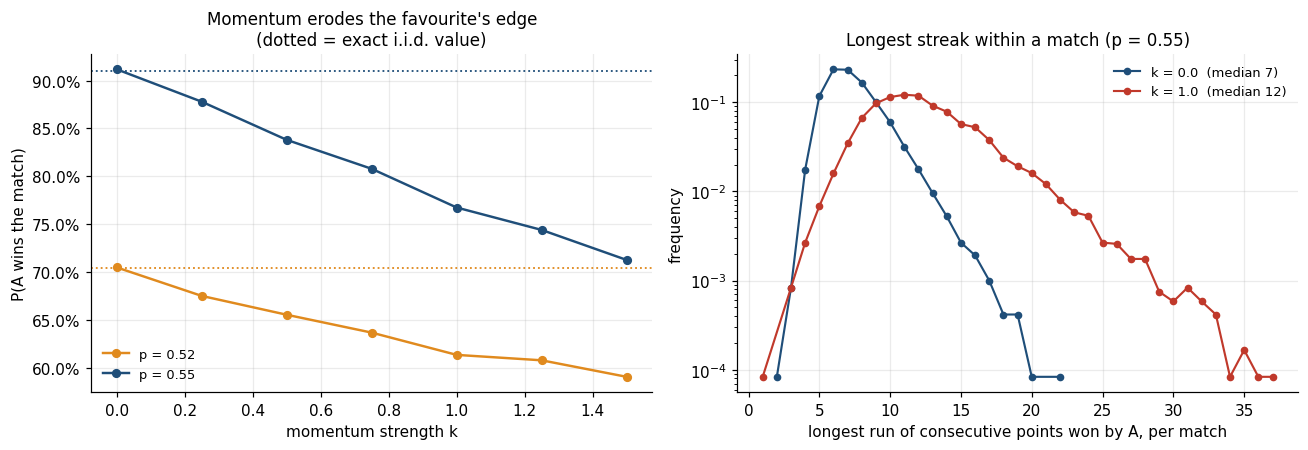

k,P(win) at p=0.52,P(win) at p=0.55,edge lost at p=0.55 (pp)
0.00,0.7048,0.9117,+0.00
0.25,0.6751,0.8779,+3.38
0.50,0.6554,0.8381,+7.37
0.75,0.6368,0.8078,+10.39
1.00,0.6135,0.7674,+14.43
1.25,0.6078,0.7440,+16.77
1.50,0.5906,0.7127,+19.91


In [25]:
k_list = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
N_MATCH = 12_000
out = {}
for p0 in (0.52, 0.55):
    wins, runs = [], []
    for i, k in enumerate(k_list):
        s = TennisSimulator(p=p0, k=k, seed=SEED + 3000 + i)
        d = s.simulate_matches(N_MATCH)
        wins.append(d["winner"].mean())
        runs.append(d["longest_run_a"])
    out[p0] = (np.array(wins), runs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
for p0, col in [(0.52, C2), (0.55, C0)]:
    w = out[p0][0]
    ax1.plot(k_list, w, "o-", color=col, ms=5, lw=1.6, label=f"p = {p0}")
    ax1.axhline(match_win_probability_iid(p0, 3), color=col, ls=":", lw=1.2)
ax1.set_xlabel("momentum strength k")
ax1.set_ylabel("P(A wins the match)")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.set_title("Momentum erodes the favourite's edge\n(dotted = exact i.i.d. value)")
ax1.legend(fontsize=8.5)

for k_idx, col in [(0, C0), (4, C1)]:
    r = out[0.55][1][k_idx]
    vals, cts = np.unique(r, return_counts=True)
    ax2.plot(vals, cts / cts.sum(), "o-", color=col, ms=4, lw=1.4,
             label=f"k = {k_list[k_idx]}  (median {np.median(r):.0f})")
ax2.set_yscale("log")
ax2.set_xlabel("longest run of consecutive points won by A, per match")
ax2.set_ylabel("frequency")
ax2.set_title("Longest streak within a match (p = 0.55)")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

df = pd.DataFrame({"k": k_list,
                   "P(win) at p=0.52": out[0.52][0],
                   "P(win) at p=0.55": out[0.55][0]})
df["edge lost at p=0.55 (pp)"] = (out[0.55][0][0] - out[0.55][0]) * 100
display(df.style.format({"k": "{:.2f}", "P(win) at p=0.52": "{:.4f}",
                         "P(win) at p=0.55": "{:.4f}",
                         "edge lost at p=0.55 (pp)": "{:+.2f}"}).hide(axis="index"))

I do enjoy being right (who doesn't!). The favourite's match-win probability falls monotonically in $k$ 
even though their point-win probability is pinned at 0.55 throughout. After all, Momentum is a variance pump.
In a barrier-crossing game variance is worth something to whoever is behind. To wit, they are less capped looking up
for some good luck rather than an already favorite player.

To me (at least) a non-obvious consequence: **a model fitted on point-level data and
aggregated under an independence assumption will systematically overprice favourites.** The
error is not in the estimate of $p$ — that is correct. It is in the aggregation. Tricky and fun.


---
## Part 7 — Long memory, and what absorbing barriers do to it

We saw in Part 4 that order-1 chain inflates the variance by $(1+\rho)/(1-\rho)$ and does 
nothing else. If we standardise correctly we directly recover normality. Indeed, the 
excess kurtosis decays to zero. Overall this kind of correlation buys overconfidence,  but not tail risk!

Since in finance tail risk is quite ubiquitous we would like to deal a bit with it as well.
Then, the obvious move is to make the memory richer — i.e., let the boost depend on the *length* of
the current streak rather than only on the last point. However, things are a bit complicated here.

**1. A streak-length model is still a Markov chain.** 
The pair *(who is on the run, how long)* is still a Markov state. Although now on a countably infinite space. 
ITherefore, if that chain is geometrically ergodic we get exponentially decaying $\rho_h$ all over again. 

**2. A linear boost breaks the model outright.** 
With $p_\ell = \sigma(\mathrm{logit}\,p + k\ell)$ the probability of losing after a run of $\ell$
is $\approx e^{-k\ell}$, which is *summable*. Therefore $\prod_\ell p_\ell > 0$. In other words: with positive
probability the run never ends and one player wins every remaining point. 
### A solution? Parameterise the hazard, not the boost!

What actually governs memory is the **tail of the run-length distribution**. Le us then specify that directly, i.e.,

$$h(\ell) \;=\; \mathbb{P}(\text{run ends next} \mid \text{run has reached } \ell)
\;=\; \frac{\beta}{\ell+\gamma}$$

The survival function can be cast in terms of Gamma functions

$$\mathbb{P}(L > \ell) \;=\;
\frac{\Gamma(\ell+1+\gamma-\beta)\,\Gamma(1+\gamma)}{\Gamma(1+\gamma-\beta)\,\Gamma(\ell+1+\gamma)}
\;\sim\; C\,\ell^{-\beta}$$

so $\beta$ is a **Pareto tail index** — the quantity a Hill estimator infers.
Summing that survival function (a Gauss ${}_2F_1$ at $1$) gives the mean in closed form,
$\mathbb{E}[L] = \gamma/(\beta-1)$ — not bad.

Here, note that the point sequence is an **alternating renewal process**: a run of A's points, then a run of
B's, then A's again, with runs independent across cycles because the hazard depends only on
the age of the current run. Averaging over cycles and applying the law of large numbers — the
renewal–reward theorem — gives A's long-run share as the *ratio of expectations*

$$p \;=\; \frac{\mathbb{E}[L_A]}{\mathbb{E}[L_A] + \mathbb{E}[L_B]}$$

and not $\mathbb{E}[L_A/(L_A+L_B)]$, which is a different number by Jensen Inequality (again beware, these are not the same thing!). 
Note that here we see why we must keep $\beta>1$: with an infinite mean run length there is no long-run
frequency to speak of. Substituting $\mathbb{E}[L]=\gamma/(\beta-1)$, the factor $(\beta-1)$
cancels, so $\gamma_A = 2\gamma p$ and $\gamma_B = 2\gamma(1-p)$ hit the target $p$ exactly
and *independently of* $\beta$.

| $\beta$ | $\mathbb{E}[L]$ | $\mathrm{Var}(L)$ | consequence for the bare process |
|---|---|---|---|
| $\beta>2$ | finite | finite | $\sum_h\rho_h<\infty$. Short memory. |
| $1<\beta<2$ | finite | **infinite** | $\rho_h\sim h^{1-\beta}$, $\sum_h\rho_h=\infty$, $\mathrm{Var}(S_n)\sim n^{3-\beta}$, $H=(3-\beta)/2$. |
| $\beta\le1$ | infinite | — | stay away territory |

### Bare process meets absorbing barrier

Above we described essentially a bare unbounded point process. All good, but that is not tennis! In tennis, a match starts at the first point, 
ends when someone has won two sets, and no run inside it can exceed 53 points. Neglecting the presence of these absorbing barriers would be 
absolutely tragic from a modelling point of view.

(*A side note here: Since $\mathbb{E}[L_A] = \gamma_A/(\beta-1)$, changing $\beta$ at fixed $\gamma$ changes the *mean*
run length as well as the *tail*. We therefore take care - as we did for the momentum one-order chain analyses - to keep
the mean fixed for different $\beta$ and change only the variance.*)

In [26]:
P, MEAN_RUN, N_MATCH = 0.55, 4.0, 15_000
PQ = P * (1 - P)
NS = (12, 24, 36, 48)          # 48 = shortest possible best-of-3, so no survivorship

CONFIGS = [
    ("i.i.d.",        dict(p=P, k=0.0), C0),
    ("order-1  k=1",  dict(p=P, k=1.0), C2),
]
for b, col in ((3.5, "#95a5a6"), (2.5, C3), (2.0, "#8e44ad"), (1.5, C1), (1.3, "#d35400")):
    CONFIGS.append((f"long  beta={b}",
                    dict(p=P, memory="long", beta=b,
                         gamma=gamma_for_mean_run(MEAN_RUN, b, P)), col))

paths_by_label, rows = {}, []
for label, kw, _ in CONFIGS:
    mp = TennisSimulator(seed=SEED, **kw).simulate_match_points(N_MATCH)
    paths_by_label[label] = mp

    lengths = np.array([len(x) for x in mp])
    runs = np.concatenate([run_lengths(x) for x in mp])
    S = np.array([[x[:n].sum() for n in NS] for x in mp])

    row = {
        "config": label,
        "P(A wins)": TennisSimulator(seed=SEED, **kw).simulate_matches(N_MATCH)["winner"].mean(),
        "points/match": lengths.mean(),
        "run mean": runs.mean(),
        "run max": runs.max(),
    }
    row.update({f"Var/npq n={n}": S[:, i].var(ddof=1) / (n * PQ) for i, n in enumerate(NS)})
    rows.append(row)

tbl = pd.DataFrame(rows).set_index("config")
display(
    tbl.style.format({"P(A wins)": "{:.4f}", "points/match": "{:.0f}",
                      "run mean": "{:.2f}", "run max": "{:.0f}",
                      **{f"Var/npq n={n}": "{:.2f}" for n in NS}})
    .set_caption(f"Measured inside {N_MATCH:,} real matches. E[L_A] fixed at {MEAN_RUN} "
                 f"for every beta, so only the tail index varies.")
)

,P(A wins),points/match,run mean,run max,Var/npq n=12,Var/npq n=24,Var/npq n=36,Var/npq n=48
config,,,,,,,,
i.i.d.,0.9059,142,2.19,23,1.01,1.00,1.00,1.00
order-1 k=1,0.7733,121,3.98,40,2.44,2.61,2.61,2.62
long beta=3.5,0.7208,114,3.76,52,2.73,3.51,3.96,4.26
long beta=2.5,0.6954,110,3.66,53,2.82,3.82,4.55,5.10
long beta=2.0,0.6787,108,3.52,53,2.84,4.07,5.01,5.80
long beta=1.5,0.6538,106,3.12,53,2.74,4.31,5.62,6.72
long beta=1.3,0.6447,108,2.71,53,2.54,4.20,5.63,6.90


A few things to comment here!

**1. The variance keeps responding to the tail.** At $n=48$, $\mathrm{Var}(S_n)/npq$ climbs
from $1.00$ (i.i.d.) through $2.62$ (order-1) to $6.90$ at $\beta=1.3$. 

**2. The maximum is completely blind to $\beta$.** From $\beta=3.5$ (finite variance) down
to $\beta=1.3$ (infinite variance), the longest run ever observed is **52 or 53, every single
time**. Slow short-memory or long memory with such absorbing barriers seems to be the same 
at this level. 

**3. The realised mean run is below the specified one, and increasingly so.** We fixed
$\mathbb{E}[L_A]=4.0$, and yet the simulation give $3.76$ at $\beta=3.5$ and
$2.71$ at $\beta=1.3$. Why? Because: the heavier the tail, the more "mass"
sits beyond what a match can probe. Therefore, the further the realised mean falls below the
specification.

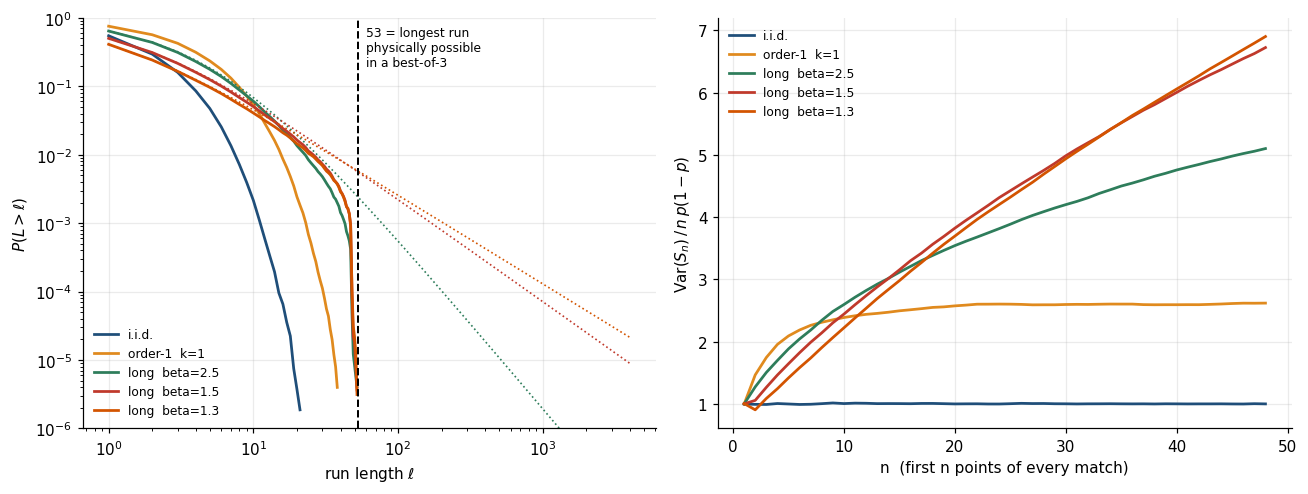

In [27]:
SHOW = ["i.i.d.", "order-1  k=1", "long  beta=2.5", "long  beta=1.5", "long  beta=1.3"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

for label, kw, col in CONFIGS:
    if label not in SHOW:
        continue
    runs = np.concatenate([run_lengths(x) for x in paths_by_label[label]])
    ell, cnt = np.unique(runs, return_counts=True)
    surv = 1.0 - np.cumsum(cnt) / cnt.sum()
    keep = surv > 0
    ax1.loglog(ell[keep], surv[keep], "-", color=col, lw=1.8, label=label)

    if kw.get("memory"):                       # the unbounded law we actually specified
        beta, gamma_a, _ = TennisSimulator(**kw).hazard_params
        e = np.arange(1, 4001)
        ax1.loglog(e, run_survival(e, beta, gamma_a), ":", color=col, lw=1.1)

    first48 = np.array([x[:48] for x in paths_by_label[label]])
    cs = np.cumsum(first48, axis=1, dtype=np.int32)
    ax2.plot(np.arange(1, 49), cs.var(axis=0, ddof=1) / (np.arange(1, 49) * PQ),
             "-", color=col, lw=1.8, label=label)

ax1.axvline(53, color="k", ls="--", lw=1.3)
ax1.text(60, 0.20, "53 = longest run\nphysically possible\nin a best-of-3", fontsize=8)
ax1.set_ylim(1e-6, 1)
ax1.set_xlabel(r"run length $\ell$")
ax1.set_ylabel(r"$P(L > \ell)$")
ax1.legend(fontsize=8, loc="lower left")

ax2.set_xlabel("n  (first n points of every match)")
ax2.set_ylabel(r"$\mathrm{Var}(S_n)\,/\,n\,p(1-p)$")
ax2.legend(fontsize=8, loc="upper left")

plt.tight_layout(); plt.show()

In the left panel each dotted line is the run-length law we *specified*, up to $\ell = 1000$. Each solid line is what the matches actually
produced, with a clear **cut-off** at $\ell = 53$. 

The right panel shows instead how the variance behave with respect to the different long-$\beta$ choices (as well as i.i.d. and momentum realisations).
We can infer something quite interesting from these graphs. To wit: **the absorbing barriers do not attenuate the regime, they kill it!**

At $\beta=1.5$ only about $0.6\%$ of runs are long enough to be clipped by the match. That could sound negligible at first. Our intuition in might tells
us that this should not matter at all. However, it is not negligible at all! This is because for $\beta<2$ those clipped runs carry *all* of the variance.
Computed on the specified (unbounded) law versus the same law truncated at 53:

| | mean run | variance of $L$ |
|---|---|---|
| as specified | 4.00 | $\infty$ |
| truncated at 53 | ~3.1 | finite, and small |

Indeed, deleting a fraction of a percent of the "mass" converts an infinite-variance process into a
well-behaved one. **A truncated power law is not a power law at all.** We can conclude that inside the match hierarchy
the process is effectively short-memory, no matter which $\beta$ we specified.

Clearly, some effect is present. Indeed, the right-hand panel shows the effect on variance at
match scale is large and still growing at $n=48$ — i.e., long memory hits hard even if clipped. However, it is reduced. 
It functionally cannot *look like* long memory at match scale. This is precisely because the runs that would produce the asymptotic
exponent are physically impossible, so the exponent is never attained and never measurable.

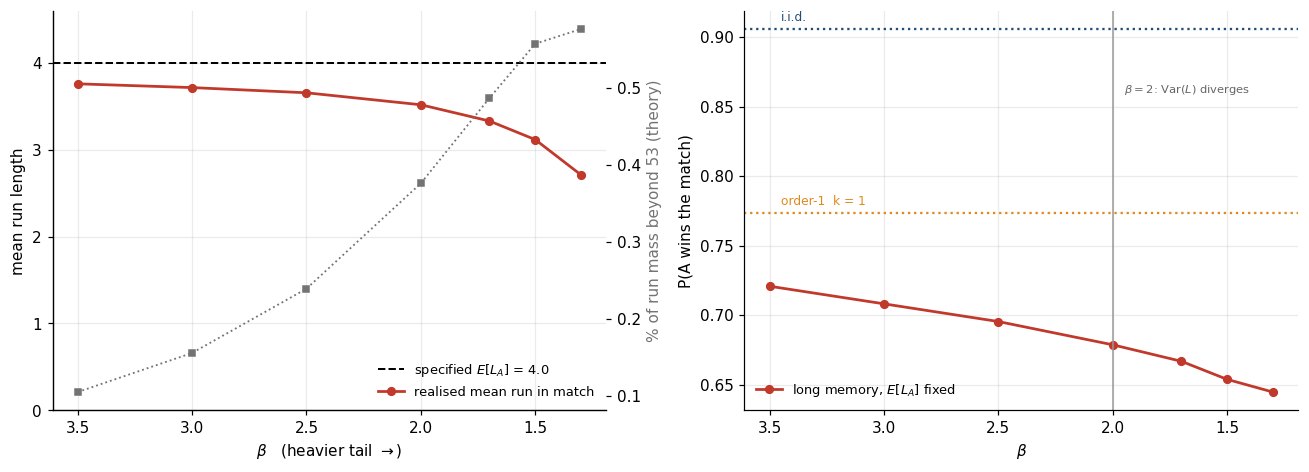

  beta  realised mean run   P(L>53) theory   P(A wins)
   3.5               3.76           0.0010      0.7208
   3.0               3.72           0.0016      0.7081
   2.5               3.66           0.0024      0.6954
   2.0               3.52           0.0038      0.6787
   1.7               3.33           0.0049      0.6668
   1.5               3.12           0.0056      0.6538
   1.3               2.71           0.0058      0.6447


In [28]:
BETAS = [3.5, 3.0, 2.5, 2.0, 1.7, 1.5, 1.3]
mean_obs, pwin, tail_mass = [], [], []

for b in BETAS:
    kw = dict(p=P, memory="long", beta=b, gamma=gamma_for_mean_run(MEAN_RUN, b, P))
    mp = TennisSimulator(seed=SEED, **kw).simulate_match_points(N_MATCH)
    mean_obs.append(np.concatenate([run_lengths(x) for x in mp]).mean())
    pwin.append(TennisSimulator(seed=SEED, **kw).simulate_matches(N_MATCH)["winner"].mean())
    beta, gamma_a, _ = TennisSimulator(**kw).hazard_params
    tail_mass.append(float(run_survival(53, beta, gamma_a)))

p_iid = TennisSimulator(p=P, k=0.0, seed=SEED).simulate_matches(N_MATCH)["winner"].mean()
p_k1 = TennisSimulator(p=P, k=1.0, seed=SEED).simulate_matches(N_MATCH)["winner"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

ax1.axhline(MEAN_RUN, color="k", ls="--", lw=1.3, label=f"specified $E[L_A]$ = {MEAN_RUN}")
ax1.plot(BETAS, mean_obs, "o-", color=C1, ms=5, lw=1.8, label="realised mean run in match")
ax1.invert_xaxis(); ax1.set_ylim(0, 4.6)
ax1.set_xlabel(r"$\beta$   (heavier tail $\rightarrow$)")
ax1.set_ylabel("mean run length")
ax1.legend(fontsize=8.5, loc="lower right")
ax1b = ax1.twinx()
ax1b.plot(BETAS, 100 * np.array(tail_mass), "s:", color="0.45", ms=4, lw=1.2)
ax1b.set_ylabel("% of run mass beyond 53 (theory)", color="0.45")
ax1b.grid(False)

ax2.axhline(p_iid, color=C0, ls=":", lw=1.5)
ax2.text(3.45, p_iid + 0.006, "i.i.d.", fontsize=8, color=C0)
ax2.axhline(p_k1, color=C2, ls=":", lw=1.5)
ax2.text(3.45, p_k1 + 0.006, "order-1  k = 1", fontsize=8, color=C2)
ax2.plot(BETAS, pwin, "o-", color=C1, ms=5, lw=1.8, label=r"long memory, $E[L_A]$ fixed")
ax2.axvline(2.0, color="0.6", lw=1)
ax2.text(1.98, 0.86, r"  $\beta=2$: $\mathrm{Var}(L)$ diverges", fontsize=7.5, color="0.4")
ax2.invert_xaxis()
ax2.set_xlabel(r"$\beta$")
ax2.set_ylabel("P(A wins the match)")
ax2.legend(fontsize=8.5, loc="lower left")

plt.tight_layout(); plt.show()

print(f"{'beta':>6} {'realised mean run':>18} {'P(L>53) theory':>16} {'P(A wins)':>11}")
for i, b in enumerate(BETAS):
    print(f"{b:>6.1f} {mean_obs[i]:>18.2f} {tail_mass[i]:>16.4f} {pwin[i]:>11.4f}")

Here, the left panel shows that as $\beta$ falls, the mass beyond 53 grows
(grey, right axis). As a consequence, the realised mean run falls away from its specification (red) due
to the format quietly deleting the part of the distribution that carries the information.

The right panel shows that holding $p=0.55$ fixed, the favourite's
match-win probability falls from $0.906$ (i.i.d.) to $0.773$ (order-1) and on down to $0.645$
at $\beta=1.3$. Here, notice there is **no discontinuity at $\beta=2$**, the point at which the 
underlying variance of $L$ becomes infinite. The phase transition that organises the entire theory 
is invisible in the match statistics. In other words: as the match never sees the region where it lives, 
the asymptotic regime is a pure fantasy never actually realised.

### Natural extensions

- **Estimation, not simulation**: given one observed match, what is the posterior over
  $(p, k)$? The answer — that it is close to uninformative — is the sharpest version of
  everything above.